# NSMC 한국어 영화 리뷰 감성 분류

NSMC(Naver Sentiment Movie Corpus)는 네이버 영화 리뷰 문장과 긍정·부정 레이블을 제공하는 한국어 감성 분석 데이터셋이다. 순환 신경망이 실제 텍스트를 처리하려면 정제·토큰화, 학습 어휘 구축, 정수 인코딩, 패딩, Embedding, 분류, 평가가 하나의 일관된 파이프라인으로 연결되어야 한다.

이 노트북은 양방향 GRU를 사용한다. 전체 파이프라인을 빠르게 실행하도록 원본 20만 건 중 클래스가 균형인 작은 표본과 4 epoch를 사용한다. 이 결과는 파이프라인 학습용이며 전체 데이터나 운영 환경의 최종 성능으로 해석하지 않는다.

기본 RNN은 긴 리뷰의 앞부분 정보를 잃기 쉽고, LSTM은 이를 보완하지만 별도 셀 상태와 세 게이트로 계산량이 늘어난다. 이 실습의 BiGRU는 두 게이트로 장기 문맥을 조절하고 리뷰 전체를 양방향으로 읽으면서 계산량을 줄이기 위한 대표 선택이다. GRU가 항상 더 우수하다는 뜻은 아니며, 실제 모델 선택은 train으로 학습하고 validation 결과를 비교한 뒤 test를 마지막 한 번의 평가에만 사용하는 경계를 따른다.


## 01. NSMC와 평가 데이터 분리

NSMC는 영화 리뷰 원문 `document`와 감성 정답 `label`을 제공하는 한국어 이진 분류 데이터셋이다. 레이블 `0`은 부정, `1`은 긍정을 뜻한다. 모델은 리뷰의 단어를 그대로 받는 것이 아니라 train에서 배운 어휘와 파라미터를 이용해 각 리뷰가 긍정일 점수를 계산한다.

평가의 의미를 지키려면 세 분할의 역할을 섞지 않아야 한다. Train은 모델 파라미터와 단어 사전을 학습하는 데이터이고, validation은 epoch와 하이퍼파라미터를 선택하는 데이터이다. Test는 선택을 모두 끝낸 모델의 일반화 성능을 마지막에 한 번 보고하는 데이터이다. Test 결과를 보고 다시 모델을 고치면 test도 선택 과정에 포함되어 독립 평가가 아니게 된다.

원본 NSMC는 train 150,000건과 test 50,000건으로 분리되어 있다. 수업에서는 결측 리뷰와 중복 문장을 제거한 뒤 원본 train에서 클래스별 1,000건을 뽑아 train·validation으로 나누고, 원본 test에서 클래스별 200건을 별도로 평가한다. 다음 코드의 출력에서 수업용 shape가 `(1600, 3)`, `(400, 3)`, `(400, 3)`이고 각 분할의 두 레이블 수가 같으며 분할 간 동일 문장 수가 모두 0인지 확인한다.

표본을 줄이면 실행은 빨라지지만 어휘 범위와 성능 추정의 안정성이 낮아진다. 따라서 이후 실행에서 얻는 정확도는 전체 NSMC 성능이 아니라 현재 작은 표본의 결과로 해석한다.

### NSMC 감성 분류 전체 흐름

그림 위쪽의 `NSMC document`는 정제·ID·Embedding을 거쳐 BiGRU 문장 벡터와 긍정 로짓으로 변환된다. `label`은 이 텍스트 처리 경로에 들어가지 않고, 세 분할에서 로짓과 `BCEWithLogitsLoss`를 계산하는 정답으로 사용한다. 손실은 train·validation·test 성능 계산에 모두 사용하지만, 역전파와 파라미터 갱신은 TRAIN에서만 수행한다.

Vocabulary는 주황색 화살표처럼 **train 토큰으로만** 만든다. Validation은 최저 validation loss 모델을 선택하는 데 사용하고, test는 모델 선택이 끝난 뒤 마지막 한 번 평가하므로 validation·test에서 Vocabulary로 되돌아가는 경로가 없다.

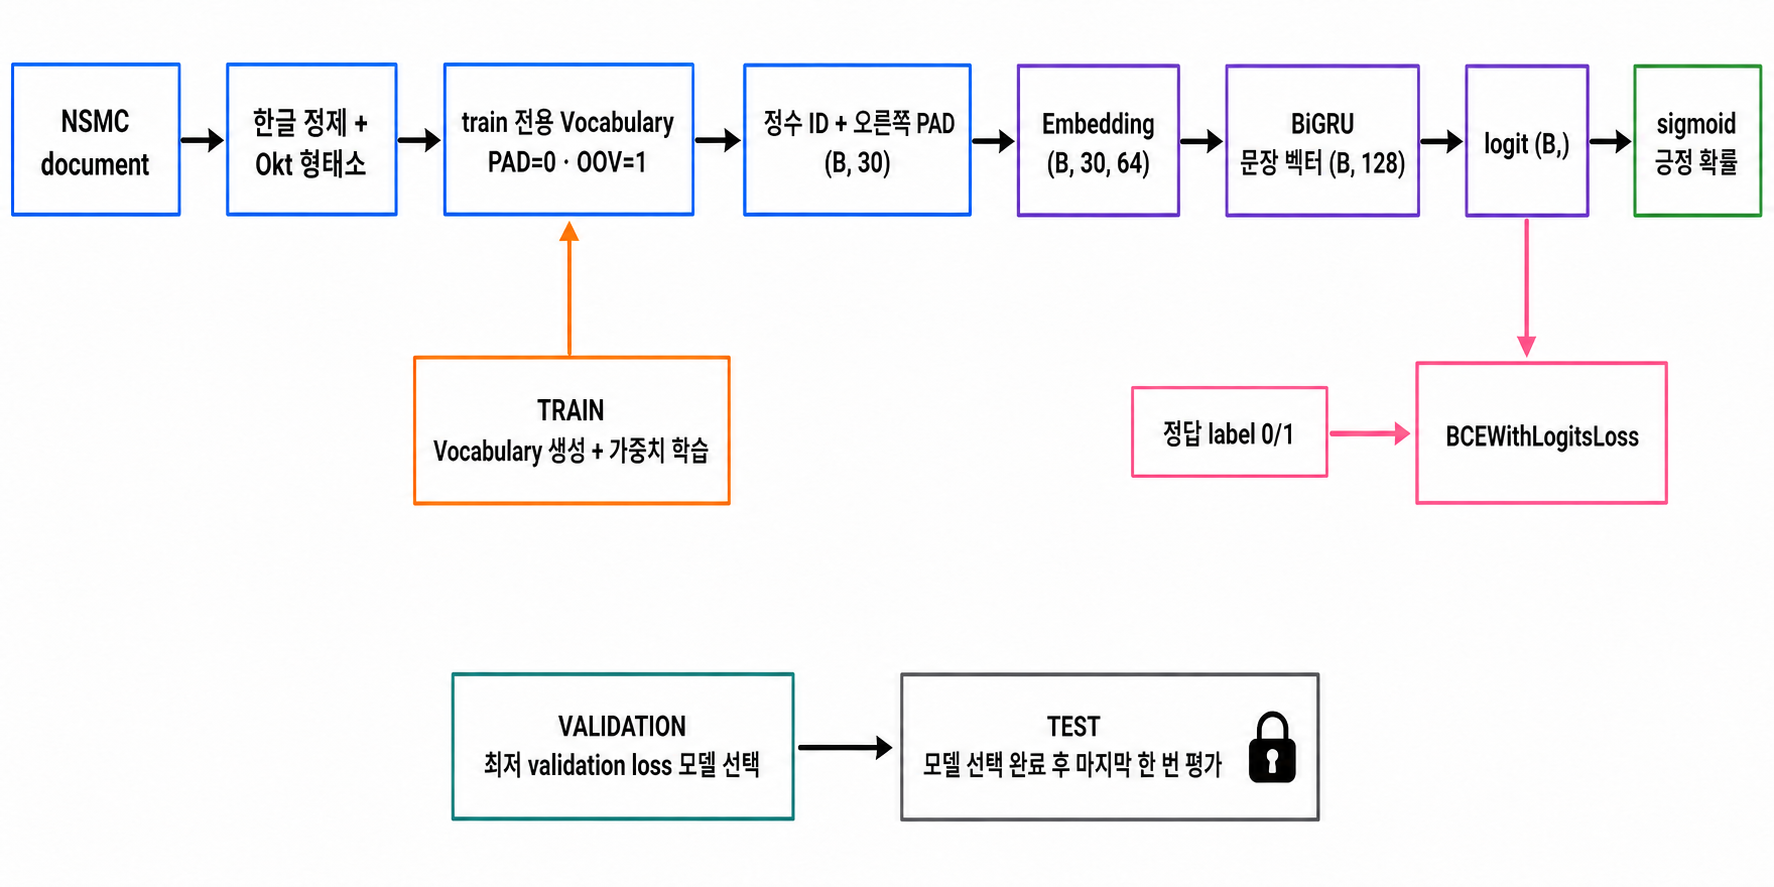


In [1]:
# NSMC 원본(20만건)을 다운로드 받고 긍정/부정(label) 비율을 일정하게 맞춰 train, validation, test 표본 생성

from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd
from sklearn.model_selection import train_test_split

data_directory = Path("data/nsmc")

data_directory.mkdir(parents=True, exist_ok=True)

train_path = data_directory / "ratings_train.txt"
test_path = data_directory / "ratings_test.txt"

urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    train_path,
)
urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    test_path,
)

full_train_df = pd.read_csv(train_path, sep="\t")
full_test_df = pd.read_csv(test_path, sep="\t")

full_train_df = (
    full_train_df
    .dropna(subset=["document"])
    .drop_duplicates(subset=["document"])
    .reset_index(drop=True)
)
full_test_df = (
    full_test_df
    .dropna(subset=["document"])
    .drop_duplicates(subset=["document"])
    .reset_index(drop=True)
)

train_candidate_df = (
    full_train_df
    .groupby("label", group_keys=False)
    .sample(n=1000, random_state=42)
    .reset_index(drop=True)
)

train_df, validation_df = train_test_split(
    train_candidate_df,
    test_size=0.2,
    random_state=42,
    stratify=train_candidate_df["label"],
)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

train_document_set = set(full_train_df["document"])
cross_duplicate_mask = full_test_df["document"].isin(train_document_set)
cross_duplicate_count = int(cross_duplicate_mask.sum())
full_test_df = (
    full_test_df.loc[~cross_duplicate_mask]
    .reset_index(drop=True)
)

test_df = (
    full_test_df
    .groupby("label", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

split_overlap_count = {
    "train-validation": len(
        set(train_df["document"])
        & set(validation_df["document"])
    ),
    "train-test": len(
        set(train_df["document"])
        & set(test_df["document"])
    ),
    "validation-test": len(
        set(validation_df["document"])
        & set(test_df["document"])
    ),
}

print("원본 정제·교차 중복 제거 후 shape:", full_train_df.shape, full_test_df.shape)
print("원본 train-test 교차 중복 제거 수:", cross_duplicate_count)
print("수업용 분할 shape:", train_df.shape, validation_df.shape, test_df.shape)
print("train 레이블 수:", train_df["label"].value_counts().sort_index().to_dict())
print("validation 레이블 수:", validation_df["label"].value_counts().sort_index().to_dict())
print("test 레이블 수:", test_df["label"].value_counts().sort_index().to_dict())
print("수업용 분할 간 동일 문장 수:", split_overlap_count)


원본 정제·교차 중복 제거 후 shape: (146182, 3) (48361, 3)
원본 train-test 교차 중복 제거 수: 796
수업용 분할 shape: (1600, 3) (400, 3) (400, 3)
train 레이블 수: {0: 800, 1: 800}
validation 레이블 수: {0: 200, 1: 200}
test 레이블 수: {0: 200, 1: 200}
수업용 분할 간 동일 문장 수: {'train-validation': 0, 'train-test': 0, 'validation-test': 0}


## 02. 한국어 정제와 형태소 토큰화

리뷰 원문에는 영문, 숫자, 이모지와 반복 기호가 섞여 있다. 현재 실습은 한국어 형태소 중심의 작은 모델이므로 한글과 공백만 남기고 연속 공백을 하나로 정규화한다.

`Okt.morphs(text, stem=True)`는 문장을 형태소로 나누고 동사·형용사의 활용형을 가능한 기본형으로 통일한다. 예를 들어 `좋았어요`를 `좋다`와 가까운 형태로 처리하여 작은 표본에서 같은 의미의 변형이 여러 어휘로 흩어지는 현상을 줄인다.

불용어는 항상 제거하는 목록이 아니다. 부정어 `안`, `못`, `없다`는 감성 판단에 중요하므로 제거하지 않고, 현재 과제에서 정보량이 적다고 판단한 일부 조사만 제외한다.


In [2]:
import re

from konlpy.tag import Okt

okt = Okt()

# 불용어 지정 : 감성 의미(긍정/부정)를 나눔에 있어서 불필요한 단어 제거 용도
stopwords = {
    "은", "는", "이", "가", "을", "를",
    "에", "의", "도", "으로", "로", "와", "과",
}

def preprocess_review(review):

    # 한글, 띄어쓰기만 남기고 모두 빈칸으로 변환
    korean_only = re.sub(
        r"[^가-힣ㄱ-ㅎㅏ-ㅣ\s]",
        " ",
        review,
    )

    # 연속된 빈칸을 하나로 줄이기 + 문장 양 끝 띄어쓰기 제거
    normalized = re.sub(
        r"\s+",
        " ",
        korean_only,
    ).strip()

    # 정규화된 문자열을 형태소 목록으로 나누고
    # stem=True -> 활용형을 기본형 중심으로 통일한다.
    tokens = okt.morphs(
        normalized,
        stem=True,
    )

    # 불용어 제거 처리 후 반환
    return [
        token
        for token in tokens
        if token not in stopwords
    ]

sample_review = "배우 연기는 좋았지만 스토리는 정말 별로였어요!!! ㅠㅠ"
sample_tokens = preprocess_review(sample_review)

print("원문:", sample_review)
print("형태소 토큰:", sample_tokens)


원문: 배우 연기는 좋았지만 스토리는 정말 별로였어요!!! ㅠㅠ
형태소 토큰: ['배우', '연기', '좋다', '스토리', '정말', '별로', '이다', 'ㅠㅠ']


### 세 분할에 같은 전처리 적용

전처리 함수는 train·validation·test에 동일하게 적용하되, 단어 빈도와 어휘 ID는 train 토큰만 이용해 만든다. 전처리 후 토큰이 하나도 남지 않는 리뷰는 이후 OOV ID 하나로 표현하여 데이터 행과 정답의 대응을 유지한다.

`progress_apply()`는 처리 진행률을 보여준다. Okt 형태소 분석은 단순 공백 분리보다 시간이 걸리므로 현재 수업용 표본 2,400건의 진행률과 빈 토큰 리뷰 수를 함께 확인한다.


In [3]:
from tqdm.auto import tqdm

# 진행률 표시 라이브러리
tqdm.pandas()

def add_tokens(dataframe):

    processed = dataframe.copy() # 원본 유지를 위해 복사

    # processed["document"] : 리뷰내용
    # apply(함수): 각 요소마다 함수 적용
    # progress_apply(함수): 각 요소마다 함수 적용되는 상황을 프로그레스바(진척도바)로 출력
    processed["tokens"] = processed["document"].progress_apply(
        preprocess_review # 전처리 함수
    )
    return processed

train_df = add_tokens(train_df)
validation_df = add_tokens(validation_df)
test_df = add_tokens(test_df)

print("train 토큰 예시:")
print(
    train_df[["document", "tokens", "label"]]
    .head(3)
    .to_string(index=False)
)

print(
    "빈 토큰 리뷰 수:",
    {
        "train": int((train_df["tokens"].str.len() == 0).sum()),
        "validation": int((validation_df["tokens"].str.len() == 0).sum()),
        "test": int((test_df["tokens"].str.len() == 0).sum()),
    },
)


  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

train 토큰 예시:
                                                                                                                                   document                                                                                                                                                                         tokens  label
개봉 후 20년 가까이 지나서 다시 봤는데 스토리나 흐름이 기억했던 것 보다 뭐랄까.그래 어설펐다. 그런데도 내내 설레서 봤다. 90년대 감성이 잘 묻어있다. n세대라 불렸고 지금보다 많이 부족한 넷환경이었지만 악플로 도배된 지금은 느낄 수 없는.. [개봉, 후, 년, 가까이, 지나다, 다시, 보다, 스토리, 나, 흐름, 기억, 하다, 것, 보다, 뭐라다, 그렇다, 어설프다, 그렇다, 내내, 설레다, 보다, 년대, 감성, 자다, 묻다, 세대, 라, 불리다, 지금, 보다, 많이, 부족하다, 넷, 환경, 이다, 악플, 도배, 되다, 지금, 느끼다, 수, 없다]      1
                                                                                             뭔가 짠하다 살면서 만나는 수많은 boulvard 들이 모두 옳은길인지 알수없지만.                                                                                                                               [뭔가, 짠하다, 살다, 만나다, 수많다, 들이다, 모두, 옳다, 인지, 알다, 없다]      1
                     

## 03. train 전용 단어 사전

단어 사전(Vocabulary)은 토큰 문자열과 모델이 처리할 정수 ID의 대응 관계이다. 같은 토큰이 항상 같은 ID로 바뀌어야 Embedding의 같은 행을 조회할 수 있다. 길이가 다른 리뷰를 한 배치의 직사각형 텐서로 만들고 train에서 보지 못한 단어도 처리하려면 두 특수 토큰이 필요하다.

- **PAD**: 길이가 짧은 문장의 빈 위치를 채우는 특수 토큰이며 현재 ID 0을 사용
- **OOV(Out Of Vocabulary)**: 단어 사전에 없는 토큰을 대신하는 특수 토큰이며 현재 ID 1을 사용

PAD와 OOV가 반드시 0과 1이어야 하는 것은 아니다. 현재 모델에서 `padding_idx=0`을 사용하고, 0을 배열의 빈 값으로 쉽게 확인하기 위해 PAD를 0으로 정한다. 그 다음 예약 번호 1을 OOV에 배정하여 실제 단어는 2부터 시작한다.

validation과 test의 단어 빈도까지 보고 어휘를 만들면 평가 데이터 정보가 학습 과정에 들어가는 데이터 누수가 발생한다. 따라서 다음 코드의 `Counter`는 train 토큰만 세고 빈도가 높은 실제 단어를 최대 4,998개 선택한다. 출력에서 PAD·OOV가 `0`, `1`이고 실제 단어 ID가 2부터 시작하는지 확인한다.


In [ ]:
from collections import Counter

maximum_vocabulary_size = 5000
PAD_ID = 0
OOV_ID = 1

token_counter = Counter(
    token
    for tokens in train_df["tokens"]
    for token in tokens
)

most_common_tokens = token_counter.most_common(
    maximum_vocabulary_size - 2
)
word_to_id = {
    "<PAD>": PAD_ID,
    "<OOV>": OOV_ID,
}

word_to_id.update(
    {
        token: index
        for index, (token, _) in enumerate(
            most_common_tokens,
            start=2,
        )
    }
)

id_to_word = {
    token_id: token
    for token, token_id in word_to_id.items()
}

print("실제 단어 사전 크기:", len(word_to_id))
print("PAD·OOV ID:", word_to_id["<PAD>"], word_to_id["<OOV>"])
print("빈도 상위 10개:", most_common_tokens[:10])
print(
    "앞 10개 ID 대응:",
    [
        (token_id, id_to_word[token_id])
        for token_id in range(min(10, len(id_to_word)))
    ],
)


### 정수 인코딩·오른쪽 패딩·실제 길이

각 토큰은 `word_to_id`에서 정수 ID로 바꾸고, 사전에 없으면 OOV ID 1을 사용한다. 현재 리뷰는 앞부분부터 최대 30개 토큰을 남기며, 짧은 리뷰의 오른쪽에는 PAD ID 0을 채운다.

`lengths`에는 PAD를 제외한 실제 토큰 수를 저장한다. 빈 토큰 리뷰는 OOV 하나로 바꾸어 최소 길이를 1로 유지한다. 이 길이는 `pack_padded_sequence()`가 PAD 위치를 GRU 계산에서 제외할 때 사용한다.

학습 전 OOV 진단은 train과 validation만 사용한다. Validation OOV 비율은 어휘 크기나 토큰화 기준을 고르는 근거가 될 수 있지만, test OOV 비율은 모델과 어휘를 모두 고정한 뒤 최종 test 평가 셀에서만 확인한다.


In [ ]:
import torch

max_length = 30

torch.manual_seed(42)

def encode_and_pad(tokens):

    token_ids = [
        word_to_id.get(token, OOV_ID)
        for token in tokens[:max_length]
    ]

    if not token_ids:
        token_ids = [OOV_ID]

    actual_length = len(token_ids)

    padded_ids = token_ids + [PAD_ID] * (
        max_length - actual_length
    )

    return padded_ids, actual_length

def encode_dataframe(dataframe):

    encoded_pairs = [
        encode_and_pad(tokens)
        for tokens in dataframe["tokens"]
    ]

    padded_sequences, lengths = zip(*encoded_pairs)

    inputs = torch.tensor(
        padded_sequences,
        dtype=torch.long,
    )
    actual_lengths = torch.tensor(
        lengths,
        dtype=torch.long,
    )
    labels = torch.tensor(
        dataframe["label"].to_numpy(),
        dtype=torch.float32,
    )
    return inputs, actual_lengths, labels

X_train, train_lengths, y_train = encode_dataframe(train_df)
X_validation, validation_lengths, y_validation = (
    encode_dataframe(validation_df)
)
X_test, test_lengths, y_test = encode_dataframe(test_df)

first_length = train_lengths[0].item()
first_token_ids = X_train[0, :first_length].tolist()

first_decoded_tokens = [
    id_to_word.get(token_id, "<OOV>")
    for token_id in first_token_ids
]

print("train 입력·길이·정답 shape:", X_train.shape, train_lengths.shape, y_train.shape)
print("validation 입력 shape:", X_validation.shape)
print("test 입력 shape:", X_test.shape)
print("첫 리뷰 실제 길이:", first_length)
print("첫 리뷰 앞쪽 ID:", first_token_ids)
print("ID를 다시 토큰으로 해석:", first_decoded_tokens)

def summarize_oov(inputs):

    actual_token_count = int(
        (inputs != PAD_ID).sum().item()
    )
    oov_count = int(
        (inputs == OOV_ID).sum().item()
    )

    return {
        "OOV 수": oov_count,
        "실제 토큰 수": actual_token_count,
        "OOV 비율": round(
            oov_count / actual_token_count,
            4,
        ),
    }

development_oov_summary = {
    "train": summarize_oov(X_train),
    "validation": summarize_oov(X_validation),
}
print(
    "학습 전 train·validation OOV 통계:",
    development_oov_summary,
)


## 04. mini-batch DataLoader

`TensorDataset`은 토큰 ID, 실제 길이와 레이블의 같은 행을 하나의 샘플로 묶는다. `DataLoader`는 여러 샘플을 mini-batch로 나누어 모델에 전달한다.

학습 DataLoader만 `shuffle=True`로 설정하여 epoch마다 배치 구성을 섞는다. validation과 test는 결과를 원래 행과 대응시키기 위해 순서를 유지한다.


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

train_dataset = TensorDataset(
    X_train,
    train_lengths,
    y_train,
)
validation_dataset = TensorDataset(
    X_validation,
    validation_lengths,
    y_validation,
)
test_dataset = TensorDataset(
    X_test,
    test_lengths,
    y_test,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

batch_token_ids, batch_lengths, batch_labels = next(
    iter(train_loader)
)

print("데이터셋 크기:", len(train_dataset), len(validation_dataset), len(test_dataset))
print("첫 배치 토큰 ID shape:", batch_token_ids.shape)
print("첫 배치 길이 shape:", batch_lengths.shape)
print("첫 배치 레이블 shape:", batch_labels.shape)
print("첫 배치 길이 범위:", batch_lengths.min().item(), batch_lengths.max().item())


## 05. Embedding+BiGRU 감성 분류 모델

모델은 정수 ID `(배치, 30)`을 Embedding 벡터 `(배치, 30, 64)`로 바꾸고, packed sequence로 PAD를 제외한 뒤 양방향 GRU에 전달한다. 한 층 BiGRU의 최종 hidden shape는 `(2, 배치, 64)`이며 두 방향을 연결하면 문장 벡터는 `(배치, 128)`이다.

`nn.Dropout(0.3)`은 학습 중 문장 벡터의 일부 특성을 무작위로 0으로 만들어 특정 특성에 지나치게 의존하는 현상을 줄인다. `nn.Linear(128, 1)`은 문장마다 긍정 클래스 로짓 하나를 출력한다.

- **로짓(Logit)**: 시그모이드를 적용해 확률로 바꾸기 전의 긍정 클래스 원시 점수


## 06. 학습과 validation

학습은 모델의 긍정 로짓과 `0`·`1` 정답 사이의 손실을 계산하고, 그 손실의 기울기로 Embedding·GRU·분류 계층의 파라미터를 갱신하는 과정이다. `BCEWithLogitsLoss`는 수치적으로 안정적인 시그모이드 계산을 포함하므로 모델 출력에는 시그모이드를 미리 적용하지 않는다. `Adam`은 역전파로 얻은 기울기를 이용해 파라미터를 갱신한다.

순환 계산은 긴 시간축을 역전파할 때 기울기가 지나치게 커질 수 있다. 기울기 norm은 모델 전체 기울기의 크기를 하나의 값으로 요약하며, gradient clipping은 `optimizer.step()` 전에 그 크기를 제한한다. 코드가 출력하는 norm은 제한하기 전 값이므로 `1.0`보다 클 수 있지만 실제 갱신에는 제한된 기울기가 사용된다.

`run_epoch()`는 optimizer가 전달되면 학습하고, 전달되지 않으면 기울기 기록 없이 validation을 수행한다. Validation은 파라미터를 갱신하지 않고 학습하지 않은 데이터의 일반화 경향을 확인하는 단계이다. 각 epoch에서 validation 손실이 가장 작은 파라미터를 메모리에 복사하고, 4 epoch가 끝난 뒤 그 상태를 다시 불러온다.

실행 후에는 고정된 수치를 기대하지 않고 train·validation의 변화 관계를 읽는다. 두 손실이 함께 감소하면 현재 표본에서 학습과 일반화가 함께 개선되는 경향이고, train 정확도만 오르면서 validation 손실이 증가하면 더 오래 학습할 근거가 아니라 과적합 가능성을 점검할 신호이다.


## 07. test 평가와 오분류 사례

Test는 validation으로 모델 선택이 끝난 뒤 한 번 평가한다. 정확도와 함께 confusion matrix와 클래스별 precision·recall·F1을 확인하면 긍정 또는 부정 한쪽에 치우친 오류를 찾을 수 있다. 이 셀의 출력 수치는 학습 결과에 따라 달라지므로 실행 전에 특정 값을 가정하지 않고 실제 표의 위치와 클래스별 차이를 읽는다.

Test OOV 통계도 이 최종 평가 단계에서 처음 확인한다. 이 값은 고정된 어휘가 test 리뷰를 얼마나 포괄했는지와 오분류 원인을 해석하는 참고 정보일 뿐이다. Test OOV를 보고 어휘 크기, 토큰화, 모델 또는 임계값을 다시 조정하지 않는다.

- **Precision**: 특정 클래스로 예측한 리뷰 중 실제로 그 클래스인 비율
- **Recall**: 실제 특정 클래스 리뷰 중 모델이 찾아낸 비율
- **F1**: precision과 recall의 조화평균
- **Confusion Matrix**: 실제 클래스 행과 예측 클래스 열의 개수를 나타내는 표

Confusion matrix의 행은 실제 클래스, 열은 예측 클래스이다. 왼쪽 위와 오른쪽 아래 대각선은 맞힌 개수이고, `실제 부정·예측 긍정`은 거짓 긍정, `실제 긍정·예측 부정`은 거짓 부정이다. 두 행의 대각선 비율과 분류 보고서의 recall을 함께 보면 어느 실제 클래스를 더 자주 놓치는지 판단할 수 있다.

오분류 리뷰는 정답 레이블 오류, 반어법, 짧은 문장, OOV와 잘린 토큰처럼 수치 지표가 알려주지 않는 실패 원인을 찾는 근거이다. 다음 코드가 출력한 오분류가 실제로 있을 때만 원문·정답·확률을 읽고 원인을 추정하며, 저장되지 않았거나 실행하지 않은 결과를 임의의 사례나 수치로 채우지 않는다.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

def predict_probabilities(
    model,
    data_loader,
    device,
):

    model.eval()

    probability_batches = []

    with torch.no_grad():

        for token_ids, lengths, _ in data_loader:
            token_ids = token_ids.to(device)
            logits = model(token_ids, lengths)

            probabilities = torch.sigmoid(
                logits
            ).cpu()
            probability_batches.append(probabilities)

    return torch.cat(probability_batches)

test_loss, test_accuracy, _ = run_epoch(
    model,
    test_loader,
    criterion,
    device,
)
test_probabilities = predict_probabilities(
    model,
    test_loader,
    device,
)

test_predictions = (
    test_probabilities >= 0.5
).long()
test_targets = y_test.long()

matrix = confusion_matrix(
    test_targets.numpy(),
    test_predictions.numpy(),
)

matrix_df = pd.DataFrame(
    matrix,
    index=["실제 부정", "실제 긍정"],
    columns=["예측 부정", "예측 긍정"],
)

test_oov_summary = summarize_oov(X_test)

print(
    f"Test Loss {test_loss:.4f} | "
    f"Test Accuracy {test_accuracy:.3f}"
)
print()
print("Test OOV 통계:", test_oov_summary)
print()
print("Confusion Matrix")
print(matrix_df.to_string())
print()

print(
    classification_report(
        test_targets.numpy(),
        test_predictions.numpy(),
        target_names=["부정", "긍정"],
        digits=3,
        zero_division=0,
    )
)

result_df = test_df[
    ["document", "label"]
].copy()
result_df["긍정확률"] = (
    test_probabilities.numpy()
)
result_df["예측"] = test_predictions.numpy()

error_examples = result_df[
    result_df["label"] != result_df["예측"]
]
print("오분류 예시")
print(
    error_examples
    .head(5)
    .to_string(index=False)
)


## 08. 결과 해석과 확장

이 실습은 1,600건 train과 4 epoch로 전체 파이프라인을 확인하는 수업용 기준선이다. 실행해서 얻는 지표는 해당 표본·난수·환경의 결과이므로 저장 출력이 없거나 실행하지 않은 상태에서는 성능을 단정하지 않는다. 성능을 개선하려면 한 번에 여러 요소를 바꾸지 않고 데이터 크기, 어휘 수, 최대 길이, hidden 크기와 학습 epoch를 validation에서 하나씩 비교한다.

운영 수준 평가에서는 여러 난수 시드, 더 큰 test 표본, 클래스별 오류와 실제 서비스 문장 분포를 함께 확인해야 한다. RNN·LSTM·GRU 비교도 같은 데이터 분할과 전처리, 비슷한 모델 용량에서 수행해야 구조 차이와 실험 조건 차이를 혼동하지 않는다.
